# Notebook 2: Plotting ZTF Light Curves

## What is a light curve?

A **light curve** is simply a time series of how bright an object is. If a star is pulsating, orbiting another star, or being eclipsed, its brightness changes over time in a periodic pattern. By measuring that pattern, we can learn about the physical properties of the system.

## What are matchfiles?

ZTF stores its calibrated photometry in **matchfiles** — large HDF5 files organized by sky region. Each matchfile covers one ZTF *field* (a patch of sky), one *CCD* (detector chip, 1–16), one *quadrant* (quarter of a CCD, 1–4), and one *filter* (g, r, or i). Inside the HDF5 file you'll find:

- `data/sources` — a table of all sources in that region (positions, reference magnitudes, IDs)
- `data/exposures` — a table of all observations (timestamps, processing IDs)
- `data/sourcedata` — the actual flux measurements, stored as a flat array indexed by (source × exposure)

In this notebook, we'll walk through the full pipeline of going from sky coordinates to a beautiful phase-folded light curve.

## Setup

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

import ztf_tools

## Step 1: Pick a source

We'll pick a known ultracompact binary from `interesting_objects.csv` — these are systems discovered by Burdge et al. (2020) in their systematic ZTF search. We know their sky positions and orbital periods, but we'll need to look up their Pan-STARRS IDs from the matchfiles in order to extract the light curves.

Alternatively, you can grab your own candidate from the catalog — see the commented-out code below.

In [2]:
import pandas as pd

objects = pd.read_csv('interesting_objects.csv', comment='#')
objects[:5]

,name,ra,dec,ps_id,period,type,notes
0,ZTF J1539+5027,234.884000,50.460756,1.685523e+17,0.004801,eclipsing double WD,6.91 min — shortest known eclipsing WD binary;...
1,ZTF J0538+1953,84.511375,19.884136,1.318608e+17,0.010030,eclipsing double WD,14.44 min — eclipsing DA WD pair with irradiation
2,ZTF J1905+3134,286.297250,31.575658,1.458929e+17,0.011946,AM CVn,17.20 min — high-state AM CVn system
3,PTF J0533+0209,83.383583,2.153197,1.105808e+17,0.014282,ellipsoidal double WD,20.57 min — ellipsoidal DBA white dwarf
4,ZTF J2029+1534,307.342958,15.575269,1.266931e+17,0.014491,eclipsing double WD,20.87 min — eclipsing DA WD pair


In [3]:
# === Option A: Pick a known object from interesting_objects.csv ===
# source = objects.iloc[0]
# ra, dec = source['ra'], source['dec']
# period = source['period']

# === Option B: Grab your own candidate from the catalog ===
# (Uncomment the lines below and comment out Option A)
catalog = ztf_tools.load_catalog('/ztf/catalogs/box_least_squares', max_files=200)
candidates = ztf_tools.filter_candidates(
    catalog, min_significance=50, max_period=180/1440
)
candidates = candidates[candidates['bls_power'] < 100]  # avoid the brightest/weirdest
source = candidates.sample(1).iloc[0]  # pick a random candidate
ra, dec = source['ra'], source['dec']
period = source['period']

name = source.get('name', f'RA={ra:.4f}, Dec={dec:.4f}')
print(f'Source: {name}')
print(f'  RA, Dec = ({ra:.4f}, {dec:.4f}) deg')
print(f'  Period  = {period:.6f} days ({period * 1440:.2f} minutes)')

Source: RA=307.5230, Dec=74.0508
  RA, Dec = (307.5230, 74.0508) deg
  Period  = 0.085555 days (123.20 minutes)


## Step 2: Find which ZTF field covers this position

ZTF divides the sky into ~900 overlapping **fields**. Each field is observed by a mosaic camera with 16 **CCDs**, each split into 4 **quadrants**. To find our source's data, we need to figure out which field(s), CCD(s), and quadrant(s) cover its sky position.

The `ztf_tools` module has internal functions for this. Let's use them directly to see what's happening under the hood:

In [4]:
field_ccd_quads = ztf_tools.get_field_id(
    ra, dec, ztf_tools._fieldno, ztf_tools._field_ra, ztf_tools._field_dec
)

print(f'This source falls in {len(field_ccd_quads)} field/CCD/quad combinations:')
for field, ccd, quad in field_ccd_quads:
    print(f'  Field {field}, CCD {ccd}, Quadrant {quad}')

This source falls in 1 field/CCD/quad combinations:
  Field 866, CCD 1, Quadrant 2


## Step 3: Open the HDF5 matchfile

Now that we know the field/CCD/quadrant, we can open the corresponding matchfile. Matchfiles are named like `data_FFFF_CC_Q_zX.h5` where FFFF is the field number, CC is the CCD, Q is the quadrant, and zX is the filter (zg, zr, or zi).

Let's open one and explore its structure:

In [5]:
# Build the matchfile path for the first field/CCD/quad, r-band
field, ccd, quad = field_ccd_quads[0]
matchfile_path = f'/ztf/matchfiles/{field:04d}/data_{field:04d}_{ccd:02d}_{quad:1d}_zr.h5'
print(f'Opening: {matchfile_path}')

Opening: /ztf/matchfiles/0866/data_0866_01_2_zr.h5


In [6]:
f = h5py.File(matchfile_path, 'r')

# Top-level structure
print('Top-level keys:', list(f.keys()))
print('Under "data":', list(f['data'].keys()))
print()
print('Sources table columns:', list(f['data']['sources'].dtype.names))
print(f'Number of sources: {len(f["data"]["sources"]):,}')
print()
print('Exposures table columns:', list(f['data']['exposures'].dtype.names))
print(f'Number of exposures: {len(f["data"]["exposures"]):,}')

Top-level keys: ['data']
Under "data": ['exposures', 'sourcedata', 'sources']

Sources table columns: ['gaia_id', 'ra', 'decl', 'mag_ref', 'mag_err_ref', 'objtype']
Number of sources: 14,782

Exposures table columns: ['jd', 'bjd', 'filterid', 'exptime', 'pid', 'field', 'ccd', 'quad', 'imstat', 'infobits', 'seeing', 'mzpsci', 'mzpsciunc', 'mzpscirms', 'clrco', 'clrcounc', 'maglim', 'airmass', 'nps1matches']
Number of exposures: 467


In [7]:
# Look up the Pan-STARRS ID by finding the nearest source to our (ra, dec)
src_ra = np.array(f['data']['sources']['ra'])
src_dec = np.array(f['data']['sources']['decl'])
dist = np.sqrt((src_ra - ra)**2 + ((src_dec - dec) * np.cos(np.deg2rad(dec)))**2)
nearest = np.argmin(dist)

ps_id = f['data']['sources'][nearest]['gaia_id']
print(f'Nearest source at offset {dist[nearest] * 3600:.2f} arcsec')
print(f'Pan-STARRS ID: {ps_id}')

Nearest source at offset 0.00 arcsec
Pan-STARRS ID: 196863075230841720


## Step 4: Extract the light curve arrays

We already found our source at index `nearest` above. Now we extract the corresponding flux data from `sourcedata`.

The flux values are **differential fluxes** — the difference between the source's flux and a reference flux. To get the total flux, we add back the reference flux (computed from the reference magnitude).

In [8]:
idx = np.array([nearest])
print(f'Source index: {idx}')

# Reference flux
mag_ref = f['data']['sources'][idx[0]]['mag_ref']
flux_ref = 10 ** (-0.4 * mag_ref)
print(f'Reference magnitude: {mag_ref:.3f}')
print(f'Reference flux: {flux_ref:.6f}')

Source index: [3017]
Reference magnitude: -6.269
Reference flux: 321.810394


In [9]:
# Extract timestamps and flux data
times_jd = np.array(f['data']['exposures']['jd'])
n_exp = len(times_jd)

# sourcedata is a flat array: source_i's data starts at index i * n_exp
start = idx[0] * n_exp
source_data = f['data']['sourcedata'][start:start + n_exp]

raw_flux = source_data['flux']
raw_flux_err = source_data['flux_err']
flags = source_data['flag']

print(f'Number of exposures: {n_exp}')
print(f'Flux range: [{np.nanmin(raw_flux):.4f}, {np.nanmax(raw_flux):.4f}]')

f.close()

Number of exposures: 467
Flux range: [-222.1846, 222.2228]


## Step 5: Convert MJD to BJD

The timestamps in the matchfile are in **JD** (Julian Date). For precise timing of periodic signals, we need to convert to **BJD** (Barycentric Julian Date) — this corrects for the Earth's motion around the Sun, which can shift the apparent arrival time of light by up to ~8 minutes. Without this correction, our phase-folded light curves would be smeared out.

In [10]:
# Clean the data first
good = (~np.isnan(raw_flux)) & (flags == 0)
t_mjd = times_jd[good] - 2400000.5  # JD → MJD
flux = raw_flux[good] + flux_ref
flux_err = raw_flux_err[good]

print(f'Good data points: {good.sum()} out of {n_exp}')

Good data points: 465 out of 467


In [11]:
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord

t = Time(t_mjd, format='mjd', scale='utc')
t_tcb = t.tcb
coord = SkyCoord(ra, dec, unit='deg')
palomar = EarthLocation.of_site('Palomar')
delta = t_tcb.light_travel_time(coord, kind='barycentric', location=palomar)
t_bjd = (t_tcb + delta).value

print(f'BJD range: {t_bjd.min():.4f} to {t_bjd.max():.4f}')
print(f'Timespan: {t_bjd.max() - t_bjd.min():.1f} days')

BJD range: 58217.4959 to 60065.4006
Timespan: 1847.9 days


## Step 6: Clip outliers

Real data always has some bad points — cosmic rays, clouds, tracking errors. We use an **IQR (interquartile range)** clip to remove extreme outliers while keeping real variability.

In [12]:
n_before = len(flux)

median = np.median(flux)
q75, q25 = np.percentile(flux, [75, 25])
iqr = q75 - q25
keep = (flux > median - 10 * iqr) & (flux < median + 10 * iqr)

t_bjd = t_bjd[keep]
flux = flux[keep]
flux_err = flux_err[keep]

print(f'Before clipping: {n_before} points')
print(f'After clipping:  {len(flux)} points')
print(f'Removed: {n_before - len(flux)} outliers')

Before clipping: 465 points
After clipping:  465 points
Removed: 0 outliers


## Step 7: Plot the raw light curve

Let's see what the light curve looks like before any phase folding:

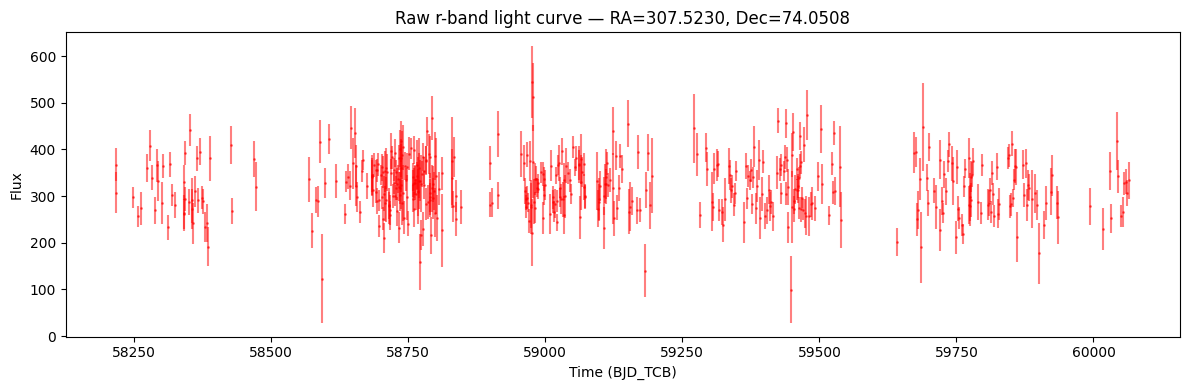

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(t_bjd, flux, flux_err, ls=' ', marker='.', ms=2, color='red', alpha=0.5)
ax.set_xlabel('Time (BJD_TCB)')
ax.set_ylabel('Flux')
ax.set_title(f'Raw r-band light curve — {name}')
fig.tight_layout()
plt.show()

## Step 8: Phase-fold and bin

**Phase folding** takes all the data points and "wraps" them at the known period, so that points separated by exactly one period overlap. This turns a sparse, multi-year time series into a dense view of a single cycle.

**Binning** averages together nearby phase points (weighted by their uncertainties) to reveal the underlying shape of the variability.

In [14]:
# Phase-fold
phases = ztf_tools.phase_fold(t_bjd, period)

# Weighted binning
bin_ph, bin_flux, bin_err = ztf_tools.weighted_bin(phases, flux, flux_err, n_bins=50)

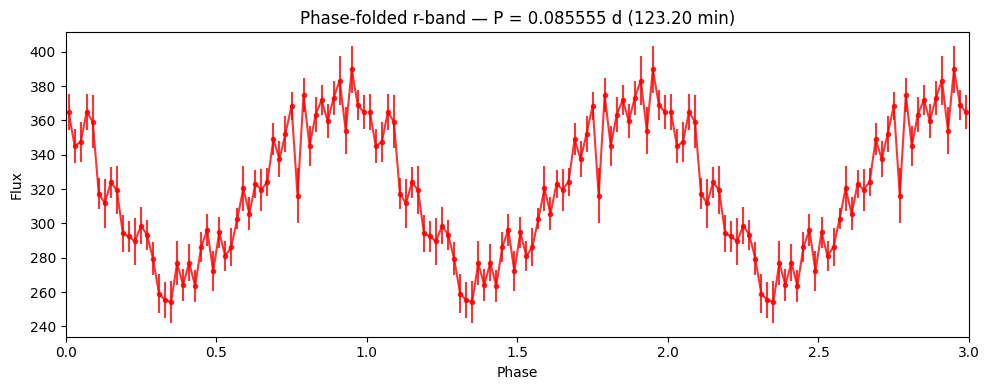

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot 3 cycles for continuity
for offset in range(3):
    ax.errorbar(bin_ph + offset, bin_flux, bin_err,
                ls='-', marker='.', color='red', alpha=0.8)

ax.set_xlabel('Phase')
ax.set_ylabel('Flux')
ax.set_title(f'Phase-folded r-band — P = {period:.6f} d ({period*1440:.2f} min)')
ax.set_xlim(0, 3)
fig.tight_layout()
plt.show()

## The easy way: using the high-level API

Everything we just did manually can be accomplished in just a few lines with `ztf_tools`. This is the recommended way to work once you understand what's happening under the hood.

**You only need (ra, dec)** — the Pan-STARRS ID is looked up automatically from the matchfile. And `lookup_period()` searches the BLS catalog (by default) to find the best-fit period, so you don't need to know it in advance either.

In [16]:
# All you need is (ra, dec) — ps_id is found automatically!
lc = ztf_tools.get_lightcurve(ra=ra, dec=dec)
print(f'Filters with data: {list(lc.keys())}')

Filters with data: ['g', 'r']


In [17]:
# Look up the period from the BLS catalog (default) or LS catalog
info = ztf_tools.lookup_period(ra=ra, dec=dec)
print(f'Catalog period: {info["period"]:.12f} days ({info["period"]*1440:.2f} min)')
print(f'BLS power:      {info["significance"]:.1f}')
print(f'Match offset:   {info["offset_arcsec"]:.2f} arcsec')

# You can also search the LS catalog instead:
# info_ls = ztf_tools.lookup_period(ra=ra, dec=dec, catalog_dir='/ztf/catalogs/lomb_scargle')

Catalog period: 0.085554745240 days (123.20 min)
BLS power:      66.1
Match offset:   0.00 arcsec


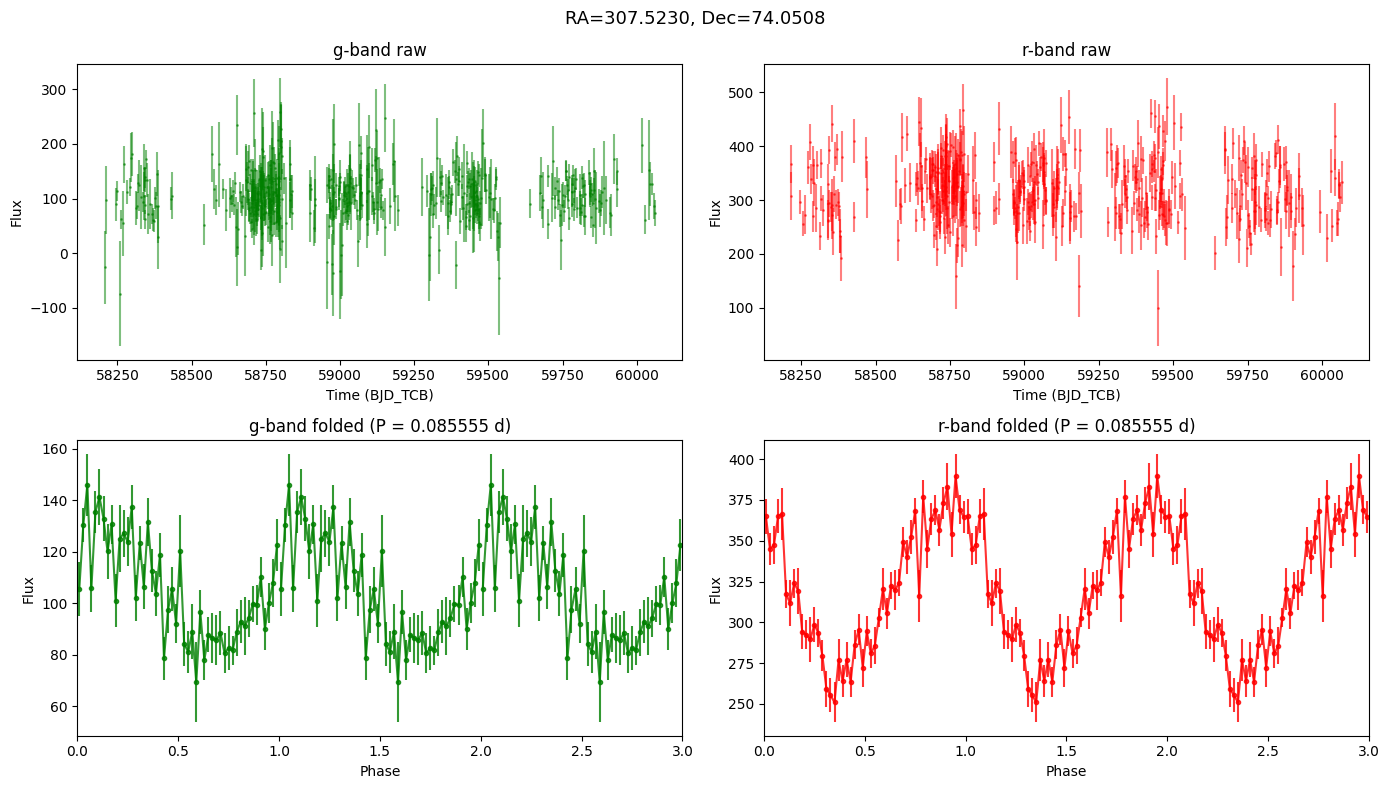

In [18]:
# Make a full diagnostic plot using the catalog period
fig = ztf_tools.plot_lightcurve(
    lc, period=info['period'],
    title=name
)
plt.show()

## Exercise

Try plotting a different source! The high-level API makes it easy — you just need coordinates.

```python
# Option A: pick a different object from the CSV
source2 = objects.iloc[4]
lc2 = ztf_tools.get_lightcurve(ra=source2['ra'], dec=source2['dec'])
info2 = ztf_tools.lookup_period(ra=source2['ra'], dec=source2['dec'])
fig2 = ztf_tools.plot_lightcurve(lc2, period=info2['period'])
plt.show()
```

```python
# Option B: type in any (ra, dec) you're curious about
lc3 = ztf_tools.get_lightcurve(ra=234.884, dec=50.461)
info3 = ztf_tools.lookup_period(ra=234.884, dec=50.461)
print(f'Period: {info3["period"]*1440:.2f} min, BLS power: {info3["significance"]:.1f}')
fig3 = ztf_tools.plot_lightcurve(lc3, period=info3['period'])
plt.show()
```

```python
# Option C: if you already know the ps_id (e.g. from the catalog), you can pass it directly
lc4 = ztf_tools.get_lightcurve(ra=234.884, dec=50.461, ps_id=168552348840033664)
```